In [1]:
# Install packages
!pip -q install geopandas pyogrio networkx scikit-learn


In [2]:
# Import tools
import json
import shutil
import zipfile
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import networkx as nx
import numpy as np
import pandas as pd
from google.colab import files
from pathlib import Path
from scipy.linalg import qr
from scipy.spatial.distance import cdist
from sklearn.metrics.pairwise import nan_euclidean_distances


In [3]:
# Set plot style
plt.rcParams.update({
    "text.usetex":False,
    "font.family":"serif",
    "font.serif":["STIXGeneral","Times New Roman","DejaVu Serif"],
    "mathtext.fontset":"stix",
    "font.size":11,
    "axes.labelsize":12,
    "axes.titlesize":13,
    "xtick.labelsize":9,
    "ytick.labelsize":9,
    "legend.fontsize":9,
    "xtick.top":False,
    "ytick.right":False,
    "xtick.direction":"out",
    "ytick.direction":"out",
    "xtick.major.size":4.5,
    "ytick.major.size":4.5,
    "xtick.major.width":.9,
    "ytick.major.width":.9,
    "axes.spines.top":False,
    "axes.spines.right":False
})
colors={"blue":"#0072B2","orange":"#D55E00","green":"#009E73","purple":"#CC79A7","gray":"#7F7F7F"}


In [4]:
# Load prospective results
uploaded=files.upload()
archives=[Path(name) for name in uploaded if name.endswith(".zip")]
if len(archives)!=1:
    raise ValueError("Upload exactly one prospective-results ZIP.")
archive=archives[0]
INPUT=Path("blind_input")
shutil.rmtree(INPUT,ignore_errors=True)
INPUT.mkdir()
required=["protocol.csv","candidates.csv","signatures.csv","target.csv","summary.csv"]
with zipfile.ZipFile(archive) as zipped:
    members={Path(name).name:name for name in zipped.namelist()}
    missing=[name for name in required if name not in members]
    if missing:
        raise FileNotFoundError("Missing files: "+", ".join(missing))
    for name in required:
        with zipped.open(members[name]) as source,open(INPUT/name,"wb") as targetfile:
            shutil.copyfileobj(source,targetfile)
print("Archive:",archive)
print("Loaded:",", ".join(required))


Saving 07-prospective.zip to 07-prospective (1).zip
Archive: 07-prospective (1).zip
Loaded: protocol.csv, candidates.csv, signatures.csv, target.csv, summary.csv


In [5]:
# Load blind protocol
protocol=pd.read_csv(INPUT/"protocol.csv")
candidates=pd.read_csv(INPUT/"candidates.csv")
data=pd.read_csv(INPUT/"signatures.csv")
target=pd.read_csv(INPUT/"target.csv")
summary=pd.read_csv(INPUT/"summary.csv")
PRIMARY=str(protocol.loc[0,"primary"])
NEIGHBORS=int(protocol.loc[0,"neighbors"])
BUDGET=int(protocol.loc[0,"budget"])
MAXBUDGET=int(protocol.loc[0,"max_budget"])
K=int(protocol.loc[0,"K"])
CLOCK=np.array([float(x) for x in str(protocol.loc[0,"clock"]).split("|")])
HORIZON=float(protocol.loc[0,"horizon"])
BSCALE=float(protocol.loc[0,"beta_scale"])
SEED=int(protocol.loc[0,"seed"])
HISTORY=[4,8,12,16]
REPEATS=25
OUT=Path("10-blind")
primary=candidates[candidates["distribution"].eq(PRIMARY)].sort_values("candidate").reset_index(drop=True)
primarydata=data[data["distribution"].eq(PRIMARY)].copy()
WINDOWS=sorted(primarydata["window"].astype(str).unique())
TRAIN=[window for window in WINDOWS if int(window[:4])<=2024]
TEST=[window for window in WINDOWS if int(window[:4])==2025]
audit=pd.DataFrame({
    "quantity":["candidate universe","candidate count","environmental windows","pre-2025 windows","held-out 2025 windows","retained K","sensor budget"],
    "value":[PRIMARY,len(primary),len(WINDOWS),len(TRAIN),len(TEST),K,BUDGET]
})
display(audit)
assert PRIMARY=="stratified"
assert len(primary)==100
assert len(WINDOWS)==25
assert len(TRAIN)==20
assert len(TEST)==5
assert K==30
assert BUDGET==10
assert MAXBUDGET==30


,quantity,value
0,candidate universe,stratified
1,candidate count,100
2,environmental windows,25
3,pre-2025 windows,20
4,held-out 2025 windows,5
5,retained K,30
6,sensor budget,10


In [6]:
# Build candidate signatures
metcols=["temp","dew","pressure","windu","windv","rain"]
sites=gpd.GeoDataFrame(primary.copy(),geometry=gpd.points_from_xy(primary["longitude"],primary["latitude"]),crs=4326).to_crs(3310)
sites=sites.sort_values("candidate").reset_index(drop=True)
ids=sites["candidate"].tolist()
xy=np.column_stack([sites.geometry.x,sites.geometry.y])
distance=cdist(xy,xy)/1000
target=target.set_index("candidate").reindex(ids)
targetweights=target["weight"].fillna(0).to_numpy(float)
targetweights=targetweights/targetweights.sum()
assert np.isclose(targetweights.sum(),1.)

def standard(values):
    values=np.asarray(values,float)
    mean=np.nanmean(values,axis=0)
    scale=np.nanstd(values,axis=0)
    scale[~np.isfinite(scale)|(scale<1e-12)]=1
    return (values-mean)/scale

def signature(windows):
    subset=primarydata[primarydata["window"].astype(str).isin(windows)].copy()
    aod=subset.pivot(index="candidate",columns="window",values="aod055").reindex(index=ids,columns=windows).to_numpy(float)
    aod=standard(aod)/np.sqrt(aod.shape[1])
    met=[]
    for column in metcols:
        values=subset.pivot(index="candidate",columns="window",values=column).reindex(index=ids,columns=windows).to_numpy(float)
        met.append(values)
    met=standard(np.column_stack(met))/np.sqrt(len(metcols)*len(windows))
    static=subset.groupby("candidate")[["elevation"]].first().reindex(ids).to_numpy(float)
    static=standard(static)
    return np.column_stack([aod,met,static])

print("Candidates:",len(ids))
print("Target weight sum:",targetweights.sum())
print("Full signature shape:",signature(WINDOWS).shape)


Candidates: 100
Target weight sum: 0.9999999999999998
Full signature shape: (100, 176)


In [7]:
# Build graph model
def graphedges(distance,k):
    order=np.argsort(distance,axis=1)[:,1:k+1]
    selected=set()
    for i in range(len(distance)):
        for j in order[i]:
            selected.add(tuple(sorted((i,int(j)))))
    complete=nx.Graph()
    complete.add_nodes_from(range(len(distance)))
    for i in range(len(distance)):
        for j in range(i+1,len(distance)):
            complete.add_edge(i,j,weight=float(distance[i,j]))
    tree=nx.minimum_spanning_tree(complete,weight="weight")
    selected.update(tuple(sorted(edge)) for edge in tree.edges())
    return sorted(selected)

def makegraph(windows):
    matrix=signature(windows)
    envdistance=nan_euclidean_distances(matrix)
    selected=graphedges(distance,NEIGHBORS)
    geovalues=np.array([distance[i,j] for i,j in selected])
    envvalues=np.array([envdistance[i,j] for i,j in selected])
    siggeo=max(np.median(geovalues),1e-12)
    sigenv=max(np.median(envvalues),1e-12)
    W=np.zeros((len(ids),len(ids)))
    for i,j in selected:
        weight=np.exp(-(distance[i,j]/siggeo)**2)*np.exp(-(envdistance[i,j]/sigenv)**2)
        W[i,j]=W[j,i]=weight
    return W

def makemodel(windows):
    W=makegraph(windows)
    values,vectors=np.linalg.eigh(np.diag(W.sum(axis=1))-W)
    basis=vectors[:,:K]
    lambdas=values[:K]
    scale=max(float(lambdas[-1]),1e-12)
    clock=CLOCK/scale
    horizon=HORIZON/scale
    decay=np.exp(-np.outer(clock,lambdas))
    blocks=basis[:,None,:]*decay[None,:,:]
    info=np.einsum("vtk,vtl->vkl",blocks,blocks)
    g=np.exp(-horizon*lambdas)*(basis.T@targetweights)
    beta=BSCALE*np.trace(info.sum(axis=0))/K
    return {"W":W,"basis":basis,"values":values,"blocks":blocks,"info":info,"g":g,"beta":beta,"K":K}

print("Graph model ready")


Graph model ready


In [8]:
# Reproduce prospective result
def risk(model,selected):
    if not len(selected):
        return 1.
    B=model["blocks"][selected].reshape(-1,model["K"])
    g=model["g"]
    beta=model["beta"]
    M=beta*np.eye(model["K"])+B.T@B
    return float(np.sqrt(beta*(g@np.linalg.solve(M,g))/(g@g)))

def taps(model,budget):
    M=model["beta"]*np.eye(model["K"])
    selected=[]
    available=np.ones(len(ids),dtype=bool)
    denominator=model["g"]@model["g"]
    for _ in range(budget):
        best=None
        bestscore=np.inf
        for candidate in np.flatnonzero(available):
            score=model["beta"]*(model["g"]@np.linalg.solve(M+model["info"][candidate],model["g"]))/denominator
            if score<bestscore-1e-14:
                best=int(candidate)
                bestscore=float(score)
        selected.append(best)
        available[best]=False
        M=M+model["info"][best]
    return selected

fullmodel=makemodel(WINDOWS)
fulltaps=taps(fullmodel,BUDGET)
rebuilt=risk(fullmodel,fulltaps)
archived=float(summary.loc[summary["result"].eq("taps_risk_10"),"value"].iloc[0])
check=pd.DataFrame({
    "quantity":["archived TAPS-10 risk","rebuilt TAPS-10 risk","absolute difference"],
    "value":[archived,rebuilt,abs(archived-rebuilt)]
})
display(check)
print("Selected sites:",[ids[i] for i in fulltaps])
assert abs(archived-rebuilt)<1e-12


,quantity,value
0,archived TAPS-10 risk,1.705838e-01
1,rebuilt TAPS-10 risk,1.705838e-01
2,absolute difference,8.604228e-16


Selected sites: ['stratified_049', 'stratified_087', 'stratified_022', 'stratified_009', 'stratified_008', 'stratified_034', 'stratified_021', 'stratified_084', 'stratified_036', 'stratified_092']


In [9]:
# Build baseline placements
def raw(model,budget):
    M=model["beta"]*np.eye(model["K"])
    selected=[]
    available=np.ones(len(ids),dtype=bool)
    for _ in range(budget):
        h=np.linalg.solve(M,model["g"])
        response=np.einsum("vtk,k->vt",model["blocks"],h)
        score=np.sum(response**2,axis=1)
        score[~available]=-np.inf
        best=int(np.argmax(score))
        selected.append(best)
        available[best]=False
        M=M+model["info"][best]
    return selected

def designs(model,budget):
    targetorder=np.argsort(-targetweights,kind="stable")[:budget].tolist()
    geographic=[int(np.argmin(distance.max(axis=1)))]
    while len(geographic)<budget:
        nearest=distance[:,geographic].min(axis=1)
        nearest[geographic]=-np.inf
        geographic.append(int(np.argmax(nearest)))
    M=model["beta"]*np.eye(model["K"])
    doptimal=[]
    available=np.ones(len(ids),dtype=bool)
    for _ in range(budget):
        best=None
        bestscore=-np.inf
        for candidate in np.flatnonzero(available):
            sign,score=np.linalg.slogdet(M+model["info"][candidate])
            if sign>0 and score>bestscore+1e-12:
                best=int(candidate)
                bestscore=float(score)
        doptimal.append(best)
        available[best]=False
        M=M+model["info"][best]
    _,_,pivots=qr(model["basis"].T,pivoting=True,mode="economic")
    return {
        "TAPS":taps(model,budget),
        "Raw response":raw(model,budget),
        "Target weight":targetorder,
        "Geographic coverage":geographic,
        "D-optimal":doptimal,
        "QR pivoting":[int(x) for x in pivots[:budget]]
    }

print("Baseline placements ready")


Baseline placements ready


In [10]:
# Build held-out model
holdout=makemodel(TEST)
oracleorder=taps(holdout,MAXBUDGET)
oraclerisk=risk(holdout,oracleorder[:BUDGET])
fullhistoryrisk=risk(holdout,fulltaps)
overlap=len(set(fulltaps)&set(oracleorder[:BUDGET]))
holdoutcheck=pd.DataFrame({
    "quantity":["2025-only oracle TAPS-10 risk","25-window TAPS evaluated on 2025","risk ratio","shared sites out of 10"],
    "value":[oraclerisk,fullhistoryrisk,fullhistoryrisk/oraclerisk,overlap]
})
display(holdoutcheck)
print("2025-only sites:",[ids[i] for i in oracleorder[:BUDGET]])


,quantity,value
0,2025-only oracle TAPS-10 risk,0.161923
1,25-window TAPS evaluated on 2025,0.171714
2,risk ratio,1.060468
3,shared sites out of 10,4.000000


2025-only sites: ['stratified_022', 'stratified_049', 'stratified_034', 'stratified_089', 'stratified_084', 'stratified_062', 'stratified_069', 'stratified_027', 'stratified_037', 'stratified_048']


In [11]:
# Create blind conditions
rng=np.random.default_rng(SEED+1000)
planrows=[]
condition=0
for history in HISTORY:
    subsets=set()
    while len(subsets)<REPEATS:
        subsets.add(tuple(sorted(rng.choice(len(TRAIN),size=history,replace=False))))
    for repeat,subset in enumerate(sorted(subsets),1):
        condition+=1
        windows=[TRAIN[i] for i in subset]
        planrows.append({
            "condition":condition,
            "history_windows":history,
            "repeat":repeat,
            "training_windows":"|".join(windows)
        })
plan=pd.DataFrame(planrows)
planaudit=plan.groupby("history_windows").size().rename("conditions").reset_index()
display(planaudit)
assert len(plan)==100
assert planaudit["conditions"].eq(REPEATS).all()
assert all(len(windows.split("|"))==history for history,windows in zip(plan["history_windows"],plan["training_windows"]))
assert all(int(window[:4])<=2024 for windows in plan["training_windows"] for window in windows.split("|"))
print("Total blind conditions:",len(plan))
print("2025 windows used for placement: 0")


,history_windows,conditions
0,4,25
1,8,25
2,12,25
3,16,25


Total blind conditions: 100
2025 windows used for placement: 0


In [12]:
# Run blind conditions
conditionrows=[]
methodrows=[]
for row in plan.itertuples(index=False):
    windows=row.training_windows.split("|")
    trainmodel=makemodel(windows)
    orders=designs(trainmodel,MAXBUDGET)
    taps10=orders["TAPS"][:BUDGET]
    tapsrisk=risk(holdout,taps10)
    oracleoverlap=len(set(taps10)&set(oracleorder[:BUDGET]))
    conditionrows.append({
        "condition":row.condition,
        "history_windows":row.history_windows,
        "repeat":row.repeat,
        "training_windows":row.training_windows,
        "blind_taps_2025_risk":tapsrisk,
        "oracle_2025_risk":oraclerisk,
        "risk_ratio_to_oracle":tapsrisk/oraclerisk,
        "oracle_site_overlap":oracleoverlap,
        "taps_sites":"|".join(ids[i] for i in taps10)
    })
    for method,order in orders.items():
        risks=np.array([risk(holdout,order[:budget]) for budget in range(1,MAXBUDGET+1)])
        matched=np.flatnonzero(risks<=tapsrisk+1e-12)
        methodrows.append({
            "condition":row.condition,
            "history_windows":row.history_windows,
            "repeat":row.repeat,
            "method":method,
            "risk_at_10":risks[BUDGET-1],
            "blind_taps_10_risk":tapsrisk,
            "sensors_to_match_taps_10":int(matched[0]+1) if len(matched) else np.nan,
            "matched_by_30":bool(len(matched)),
            "beats_taps_at_10":bool(risks[BUDGET-1]<tapsrisk-1e-12)
        })
    if row.condition%10==0:
        print(f"Finished {row.condition}/100")
conditions=pd.DataFrame(conditionrows)
methods=pd.DataFrame(methodrows)
assert len(conditions)==100
assert len(methods)==600
assert methods.groupby("method").size().eq(100).all()
print("Completed:",len(conditions))


Finished 10/100
Finished 20/100
Finished 30/100
Finished 40/100
Finished 50/100
Finished 60/100
Finished 70/100
Finished 80/100
Finished 90/100
Finished 100/100
Completed: 100


In [13]:
# Summarize blind results
historysummary=(
    conditions.groupby("history_windows")
    .agg(
        conditions=("condition","size"),
        median_risk_ratio=("risk_ratio_to_oracle","median"),
        q25_risk_ratio=("risk_ratio_to_oracle",lambda x:x.quantile(.25)),
        q75_risk_ratio=("risk_ratio_to_oracle",lambda x:x.quantile(.75)),
        p90_risk_ratio=("risk_ratio_to_oracle",lambda x:x.quantile(.90)),
        within_10_percent=("risk_ratio_to_oracle",lambda x:(x<=1.10).mean()),
        within_20_percent=("risk_ratio_to_oracle",lambda x:(x<=1.20).mean()),
        median_site_overlap=("oracle_site_overlap","median")
    )
    .reset_index()
)
methodsummary=(
    methods[~methods["method"].eq("TAPS")]
    .groupby("method")
    .agg(
        conditions=("condition","size"),
        taps_wins=("beats_taps_at_10",lambda x:(~x).sum()),
        baseline_wins=("beats_taps_at_10","sum"),
        matched_by_30=("matched_by_30","sum"),
        failed_by_30=("matched_by_30",lambda x:(~x).sum())
    )
    .reset_index()
)
display(historysummary.round(4))
display(methodsummary)


,history_windows,conditions,median_risk_ratio,q25_risk_ratio,q75_risk_ratio,p90_risk_ratio,within_10_percent,within_20_percent,median_site_overlap
0,4,25,1.1663,1.1040,1.3327,2.4564,0.20,0.60,4.0
1,8,25,1.0821,1.0632,1.1390,1.1796,0.64,0.96,5.0
2,12,25,1.0704,1.0494,1.0869,1.1092,0.84,0.96,4.0
3,16,25,1.0734,1.0519,1.0999,1.1386,0.76,0.96,4.0


,method,conditions,taps_wins,baseline_wins,matched_by_30,failed_by_30
0,D-optimal,100,100,0,30,70
1,Geographic coverage,100,100,0,69,31
2,QR pivoting,100,100,0,32,68
3,Raw response,100,96,4,100,0
4,Target weight,100,95,5,100,0


In [14]:
# Quantify TAPS advantage
baselines=["Target weight","Raw response","Geographic coverage","D-optimal","QR pivoting"]
riskwide=methods.pivot(index="condition",columns="method",values="risk_at_10").sort_index()
bestbaseline=riskwide[baselines].min(axis=1)
bestmethod=riskwide[baselines].idxmin(axis=1)
tapsstrict=riskwide["TAPS"]<bestbaseline-1e-12
effectrows=[]
for method in baselines:
    ratio=riskwide[method]/riskwide["TAPS"]
    effectrows.append({
        "method":method,
        "conditions":len(ratio),
        "taps_wins":int((ratio>1+1e-12).sum()),
        "median_baseline_over_taps":ratio.median(),
        "q10":ratio.quantile(.10),
        "q25":ratio.quantile(.25),
        "q75":ratio.quantile(.75),
        "q90":ratio.quantile(.90)
    })
effects=pd.DataFrame(effectrows)
history816conditions=conditions[conditions["history_windows"].isin([8,12,16])].copy()
history816riskwide=methods[methods["history_windows"].isin([8,12,16])].pivot(index="condition",columns="method",values="risk_at_10")
history816strict=history816riskwide["TAPS"]<history816riskwide[baselines].min(axis=1)-1e-12
display(effects.round(4))
print("TAPS strictly best:",f"{tapsstrict.sum()}/100")
print("TAPS strictly best with 8-16 windows:",f"{history816strict.sum()}/75")


,method,conditions,taps_wins,median_baseline_over_taps,q10,q25,q75,q90
0,Target weight,100,95,1.3922,1.1768,1.3205,1.4198,1.4522
1,Raw response,100,96,1.1693,1.0773,1.1261,1.2604,2.7077
2,Geographic coverage,100,100,4.6812,3.9569,4.4403,4.7740,4.8832
3,D-optimal,100,100,4.8816,3.2409,3.3696,5.4640,5.6095
4,QR pivoting,100,100,5.1396,3.2341,3.3873,5.5054,5.6427


TAPS strictly best: 92/100
TAPS strictly best with 8-16 windows: 73/75


In [15]:
# Inspect TAPS exceptions
exceptions=pd.DataFrame({
    "condition":riskwide.index,
    "taps_risk":riskwide["TAPS"],
    "best_baseline":bestmethod,
    "best_baseline_risk":bestbaseline
}).reset_index(drop=True)
exceptions["taps_over_best"]=exceptions["taps_risk"]/exceptions["best_baseline_risk"]
exceptions=exceptions[exceptions["taps_over_best"]>1+1e-12].copy()
exceptions=exceptions.merge(conditions[["condition","history_windows","training_windows"]],on="condition",how="left")
display(exceptions[["condition","history_windows","best_baseline","taps_risk","best_baseline_risk","taps_over_best"]].round(4))
display(exceptions.groupby(["history_windows","best_baseline"]).size().rename("conditions").reset_index())
print("TAPS exceptions:",len(exceptions))


,condition,history_windows,best_baseline,taps_risk,best_baseline_risk,taps_over_best
0,2,4,Raw response,0.4584,0.2376,1.9293
1,6,4,Target weight,0.4159,0.2438,1.7058
2,7,4,Target weight,0.3940,0.2438,1.6163
3,8,4,Raw response,0.2158,0.1830,1.1795
4,9,4,Target weight,0.4002,0.2438,1.6416
5,11,4,Raw response,0.1889,0.1857,1.0168
6,55,12,Target weight,0.4026,0.2438,1.6515
7,82,16,Raw response,0.2066,0.2007,1.0296


,history_windows,best_baseline,conditions
0,4,Raw response,3
1,4,Target weight,3
2,12,Target weight,1
3,16,Raw response,1


TAPS exceptions: 8


In [16]:
# Set cost benchmark
EPA_ANNUAL_COST=22456.
sources=pd.DataFrame({
    "benchmark":["Continuous PM2.5 monitor average annualized cost"],
    "cost":[EPA_ANNUAL_COST],
    "units":["USD per monitor-year"],
    "source":["EPA OIG, 2025 (costs as of January 2025)"],
    "url":["https://www.epa.gov/system/files/documents/2025-09/2-_epaoig_20250917-25-e-0051_cert_redacted_cert_0-full-report.pdf"],
    "note":["Average after accounting for one-time expenses and operation and maintenance"]
})
costpairs=methods[methods["method"].isin(["Target weight","Raw response"])].copy()
assert costpairs["matched_by_30"].all()
costpairs["extra_sites_vs_taps10"]=costpairs["sensors_to_match_taps_10"]-BUDGET
costpairs["illustrative_annualized_cost_difference"]=costpairs["extra_sites_vs_taps10"]*EPA_ANNUAL_COST
history816cost=costpairs[costpairs["history_windows"].isin([8,12,16])].copy()
display(sources)


,benchmark,cost,units,source,url,note
0,Continuous PM2.5 monitor average annualized cost,22456.0,USD per monitor-year,"EPA OIG, 2025 (costs as of January 2025)",https://www.epa.gov/system/files/documents/202...,Average after accounting for one-time expenses...


In [17]:
# Audit cost robustness
costrows=[]
for group,frame in [("All 100",costpairs),("8-16 windows",history816cost)]:
    for method in ["Target weight","Raw response"]:
        subset=frame[frame["method"].eq(method)]
        extra=subset["extra_sites_vs_taps10"]
        costrows.append({
            "history_group":group,
            "method":method,
            "conditions":len(subset),
            "median_extra_sites":extra.median(),
            "q25_extra_sites":extra.quantile(.25),
            "q75_extra_sites":extra.quantile(.75),
            "fraction_at_least_3":(extra>=3).mean(),
            "fraction_at_least_5":(extra>=5).mean(),
            "fraction_at_least_7":(extra>=7).mean(),
            "median_illustrative_annualized_cost":subset["illustrative_annualized_cost_difference"].median(),
            "q25_illustrative_annualized_cost":subset["illustrative_annualized_cost_difference"].quantile(.25),
            "q75_illustrative_annualized_cost":subset["illustrative_annualized_cost_difference"].quantile(.75)
        })
costs=pd.DataFrame(costrows)
display(costs.round(3))


,history_group,method,conditions,median_extra_sites,q25_extra_sites,q75_extra_sites,fraction_at_least_3,fraction_at_least_5,fraction_at_least_7,median_illustrative_annualized_cost,q25_illustrative_annualized_cost,q75_illustrative_annualized_cost
0,All 100,Target weight,100,5.0,4.0,5.0,0.900,0.670,0.050,112280.0,89824.0,112280.0
1,All 100,Raw response,100,7.0,5.0,9.0,0.910,0.820,0.570,157192.0,112280.0,202104.0
2,8-16 windows,Target weight,75,5.0,5.0,5.0,0.973,0.787,0.067,112280.0,112280.0,112280.0
3,8-16 windows,Raw response,75,7.0,6.0,9.5,0.933,0.893,0.613,157192.0,134736.0,213332.0


In [18]:
# Build final summary
headline=pd.DataFrame({
    "result":[
        "blind histories",
        "TAPS strictly best overall",
        "8-16 window blind histories",
        "TAPS strictly best with 8-16 windows",
        "8-16 windows within 20 percent of future oracle",
        "target-weight median extra sites",
        "raw-response median extra sites",
        "target-weight illustrative annualized cost difference",
        "raw-response illustrative annualized cost difference"
    ],
    "value":[
        len(conditions),
        int(tapsstrict.sum()),
        len(history816conditions),
        int(history816strict.sum()),
        int((history816conditions["risk_ratio_to_oracle"]<=1.20).sum()),
        history816cost.loc[history816cost["method"].eq("Target weight"),"extra_sites_vs_taps10"].median(),
        history816cost.loc[history816cost["method"].eq("Raw response"),"extra_sites_vs_taps10"].median(),
        history816cost.loc[history816cost["method"].eq("Target weight"),"illustrative_annualized_cost_difference"].median(),
        history816cost.loc[history816cost["method"].eq("Raw response"),"illustrative_annualized_cost_difference"].median()
    ]
})
display(headline)


,result,value
0,blind histories,100.0
1,TAPS strictly best overall,92.0
2,8-16 window blind histories,75.0
3,TAPS strictly best with 8-16 windows,73.0
4,8-16 windows within 20 percent of future oracle,72.0
5,target-weight median extra sites,5.0
6,raw-response median extra sites,7.0
7,target-weight illustrative annualized cost dif...,112280.0
8,raw-response illustrative annualized cost diff...,157192.0


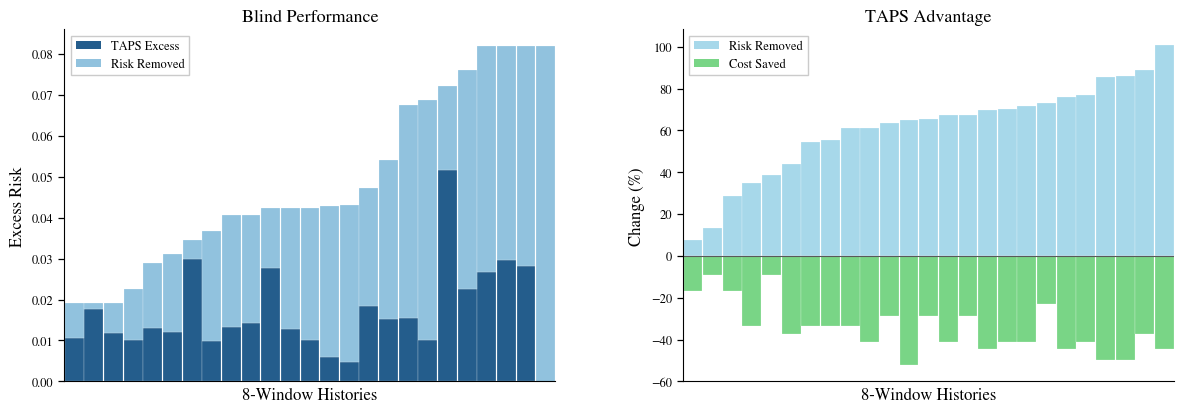

TAPS beats best practical baseline: 25 /25
Median baseline excess risk removed: 65.7 %
Median annualized monitor cost saved: 37.5 %
Median baseline sites: 16.0 vs TAPS: 10


In [19]:
# Plot blind summary
WINDOWS=8
practical=methods[
    methods["history_windows"].eq(WINDOWS)
    & methods["method"].isin(["Target weight","Raw response"])
].copy()
oracle=conditions[conditions["history_windows"].eq(WINDOWS)][["condition","oracle_2025_risk"]].copy()
rows=[]
for condition,group in practical.groupby("condition",sort=True):
    best=group.loc[group["risk_at_10"].idxmin()]
    rows.append({
        "condition":int(condition),
        "baseline":str(best["method"]),
        "taps_risk":float(best["blind_taps_10_risk"]),
        "baseline_risk":float(best["risk_at_10"]),
        "baseline_sites":float(best["sensors_to_match_taps_10"])
    })
comparison=pd.DataFrame(rows).merge(oracle,on="condition",how="left")
comparison["taps_excess"]=comparison["taps_risk"]-comparison["oracle_2025_risk"]
comparison["risk_removed"]=comparison["baseline_risk"]-comparison["taps_risk"]
comparison["baseline_excess"]=comparison["baseline_risk"]-comparison["oracle_2025_risk"]
comparison["excess_removed_pct"]=100*(comparison["baseline_risk"]-comparison["taps_risk"])/(comparison["baseline_risk"]-comparison["oracle_2025_risk"])
comparison["monitor_cost_saved_pct"]=100*(comparison["baseline_sites"]-10)/comparison["baseline_sites"]
left=comparison.sort_values(["baseline_excess","condition"]).reset_index(drop=True)
right=comparison.sort_values(["excess_removed_pct","condition"]).reset_index(drop=True)
fig,axes=plt.subplots(1,2,figsize=(12.4,4.4),gridspec_kw={"wspace":.26})
ax1,ax2=axes
x=np.arange(len(left))
tapscolor="#245D8C"
removedcolor="#91C2DE"
ax1.bar(x,left["taps_excess"],width=.96,color=tapscolor,edgecolor="white",linewidth=.15)
ax1.bar(x,left["risk_removed"],bottom=left["taps_excess"],width=.96,color=removedcolor,edgecolor="white",linewidth=.15)
ax1.set(xlim=(-.5,len(left)-.5),xticks=[],title="Blind Performance",xlabel="8-Window Histories",ylabel="Excess Risk")
ax1.set_ylim(0,ax1.get_ylim()[1])
ax1.legend(
    handles=[Patch(facecolor=tapscolor,label="TAPS Excess"),Patch(facecolor=removedcolor,label="Risk Removed")],
    loc="upper left",frameon=True,fancybox=False,edgecolor=".75"
)
x=np.arange(len(right))
riskcolor="#A7D8EA"
costcolor="#79D586"
ax2.bar(x,right["excess_removed_pct"],width=.96,color=riskcolor,edgecolor="white",linewidth=.15)
ax2.bar(x,-right["monitor_cost_saved_pct"],width=.96,color=costcolor,edgecolor="white",linewidth=.15)
ax2.axhline(0,color=".35",linewidth=.8)
ax2.set(xlim=(-.5,len(right)-.5),xticks=[],title="TAPS Advantage",xlabel="8-Window Histories",ylabel="Change (%)")
ax2.legend(
    handles=[Patch(facecolor=riskcolor,label="Risk Removed"),Patch(facecolor=costcolor,label="Cost Saved")],
    loc="upper left",frameon=True,fancybox=False,edgecolor=".75"
)
for ax in axes:
    ax.tick_params(direction="out",length=4.5,width=.9)
fig.subplots_adjust(left=.09,right=.985,bottom=.16,top=.96,wspace=.26)
fig.savefig("blind.png",dpi=300,bbox_inches="tight",pad_inches=.04,facecolor="white")
plt.show()
print("TAPS beats best practical baseline:",int((comparison["risk_removed"]>0).sum()),"/25")
print("Median baseline excess risk removed:",round(comparison["excess_removed_pct"].median(),1),"%")
print("Median annualized monitor cost saved:",round(comparison["monitor_cost_saved_pct"].median(),1),"%")
print("Median baseline sites:",comparison["baseline_sites"].median(),"vs TAPS: 10")


In [20]:
# Print final claims
print("100 blind pre-deployment histories: TAPS strictly best in",f"{tapsstrict.sum()}/100")
print("8-16 window histories: TAPS strictly best in",f"{history816strict.sum()}/75")
print("8-16 window histories within 20% of oracle:",f"{(history816conditions['risk_ratio_to_oracle']<=1.20).sum()}/75")
for group,frame in [("All 100",costpairs),("8-16 windows",history816cost)]:
    print()
    print(group)
    for method in ["Target weight","Raw response"]:
        subset=frame[frame["method"].eq(method)]
        median=subset["extra_sites_vs_taps10"].median()
        q25=subset["extra_sites_vs_taps10"].quantile(.25)
        q75=subset["extra_sites_vs_taps10"].quantile(.75)
        count=int((subset["extra_sites_vs_taps10"]>=5).sum())
        annual=subset["illustrative_annualized_cost_difference"].median()
        print(f"{method}: median extra sites = {median:.0f}, IQR = ({q25:g}, {q75:g}), >=5 extra sites = {count}/{len(subset)}, illustrative annualized cost = ${annual:,.0f}/yr")


100 blind pre-deployment histories: TAPS strictly best in 92/100
8-16 window histories: TAPS strictly best in 73/75
8-16 window histories within 20% of oracle: 72/75

All 100
Target weight: median extra sites = 5, IQR = (4, 5), >=5 extra sites = 67/100, illustrative annualized cost = $112,280/yr
Raw response: median extra sites = 7, IQR = (5, 9), >=5 extra sites = 82/100, illustrative annualized cost = $157,192/yr

8-16 windows
Target weight: median extra sites = 5, IQR = (5, 5), >=5 extra sites = 59/75, illustrative annualized cost = $112,280/yr
Raw response: median extra sites = 7, IQR = (6, 9.5), >=5 extra sites = 67/75, illustrative annualized cost = $157,192/yr


In [21]:
# Archive blind results
shutil.rmtree(OUT,ignore_errors=True)
OUT.mkdir()
blindprotocol=pd.DataFrame([{
    "notebook":"10-blind.ipynb",
    "input_archive":archive.name,
    "candidate_universe":PRIMARY,
    "candidate_count":len(ids),
    "history_sizes":"|".join(map(str,HISTORY)),
    "conditions_per_history":REPEATS,
    "conditions":len(conditions),
    "placement_years":"2021-2024",
    "evaluation_year":2025,
    "sensor_budget":BUDGET,
    "max_budget":MAXBUDGET,
    "seed":SEED,
    "ground_monitor_pm25_at_candidates":False
}])
tables={
    "protocol.csv":blindprotocol,
    "conditions.csv":conditions,
    "methods.csv":methods,
    "history.csv":historysummary,
    "method_summary.csv":methodsummary,
    "effects.csv":effects,
    "exceptions.csv":exceptions,
    "costs.csv":costs,
    "sources.csv":sources,
    "summary.csv":headline
}
for name,frame in tables.items():
    frame.to_csv(OUT/name,index=False)
shutil.copy("blind.png",OUT/"blind.png")
manifest={
    "notebook":"10-blind.ipynb",
    "purpose":"Blind prospective TAPS placement from pre-2025 exogenous environmental histories with 2025 held out for evaluation",
    "input_archive":archive.name,
    "candidate_universe":PRIMARY,
    "candidate_count":len(ids),
    "conditions":len(conditions),
    "history_sizes":HISTORY,
    "conditions_per_history":REPEATS,
    "placement_years":[2021,2024],
    "evaluation_year":2025,
    "ground_monitor_pm25_at_candidates_used":False,
    "sensor_budget":BUDGET,
    "max_budget":MAXBUDGET,
    "epa_average_annualized_cost_per_continuous_pm25_monitor":EPA_ANNUAL_COST,
    "cost_interpretation":"Illustrative translation of observed site-count differences; not measured deployment savings.",
    "twenty_percent_threshold":"Descriptive reference threshold, not a prespecified success criterion.",
    "seed":SEED
}
with open(OUT/"manifest.json","w") as file:
    json.dump(manifest,file,indent=2)
archiveout=Path("10-blind.zip")
if archiveout.exists():
    archiveout.unlink()
with zipfile.ZipFile(archiveout,"w",compression=zipfile.ZIP_DEFLATED) as zipped:
    for path in sorted(OUT.iterdir()):
        zipped.write(path,arcname=path.name)
print("Saved:",archiveout)
files.download(str(archiveout))


Saved: 10-blind.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>